In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import PIL
import torch
import torch.nn as nn
import torch.optim as optim
import torchinfo
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

In [13]:
class CustomTestDataset(Dataset):
    """
    A custom PyTorch Dataset for loading images from a flat directory structure,
    typically used for unlabelled test data in competitions.
    """
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the test images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        # Filter for common image file extensions
        self.image_files = sorted([f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])
        print(f"Found {len(self.image_files)} test images in {root_dir}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = PIL.Image.open(img_name).convert("RGB") # Ensure RGB conversion

        if self.transform:
            image = self.transform(image)

        # For test data, we don't have labels. Return a dummy label (e.g., 0)
        # The predict function will ignore this label.
        return image, 0 # Dummy label


In [14]:
def setup_device():
    """
    Automatically detect and set up the best available device for training.

    Returns:
        str: Device string ('cuda', 'mps', or 'cpu')
    """
    if torch.cuda.is_available():
        device = "cuda"
        print(f"Using CUDA GPU: {torch.cuda.get_device_name()}")
    elif torch.backends.mps.is_available():
        device = "mps"
        print("Using Apple Metal Performance Shaders (MPS)")
    else:
        device = "cpu"
        print("Using CPU")
    return device

def setup_data_directories(base_dir="crop pictures"):
    """
    Set up and validate data directory paths.

    Args:
        base_dir (str): Base directory containing train/val/test folders.

    Returns:
        dict: Dictionary containing paths to train, val, and test directories.
    """
    directories = {
        'train': os.path.join(base_dir, "train"),
        'val': os.path.join(base_dir, "val"),
        'test': os.path.join(base_dir, "test") # 'test' here refers to the unlabelled submission data
    }

    # Validate directories exist
    for split, path in directories.items():
        if os.path.exists(path):
            print(f"{split.capitalize()} Data Directory: {path} ✓")
        else:
            print(f"Warning: {split.capitalize()} directory not found: {path}")

    return directories

def get_class_information(train_dir):
    """
    Extract class names and number of classes from the training directory.

    Args:
        train_dir (str): Path to training directory.

    Returns:
        tuple: (classes list, number of classes).
    """
    if not os.path.exists(train_dir):
        raise FileNotFoundError(f"Training directory not found: {train_dir}")

    # Ensure we only list actual directories (classes)
    classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

    print(f"Found {len(classes)} classes: {classes}")
    return classes, len(classes)


In [15]:
def class_counts(dataset):
    """
    Counts the number of samples per class in a labelled dataset (ImageFolder).

    Args:
        dataset: A PyTorch Dataset object (expected to be torchvision.datasets.ImageFolder).

    Returns:
        A pandas Series with class names as index and counts as values.
    """
    counts = {}
    if hasattr(dataset, 'targets') and hasattr(dataset, 'classes'):
        for label_idx in dataset.targets:
            class_name = dataset.classes[label_idx]
            counts[class_name] = counts.get(class_name, 0) + 1
    elif isinstance(dataset, CustomTestDataset):
        # CustomTestDataset is unlabelled, so we just count total images.
        return pd.Series({'unlabelled': len(dataset)})
    else:
        print("Warning: Dataset does not have 'targets' or 'classes' attribute directly. "
              "Falling back to iterating through dataset, which can be slow.")
        # This fallback iterates through the dataset to get labels
        # It assumes dataset[i][1] gives the label
        for i in tqdm(range(len(dataset)), desc="Counting classes"):
            _, label = dataset[i]
            class_name = getattr(dataset, 'classes', {}).get(label, f"Class_{label}") # Try to get class name
            counts[class_name] = counts.get(class_name, 0) + 1
    return pd.Series(counts)

def analyze_class_distribution(dataset, dataset_name="Dataset"):
    """
    Analyze and print class distribution for a dataset.

    Args:
        dataset: PyTorch Dataset object.
        dataset_name (str): Name of the dataset for display.

    Returns:
        pd.Series: Class distribution as pandas Series.
    """
    print(f"\nAnalyzing {dataset_name}...")
    distribution = class_counts(dataset)
    total_samples = distribution.sum()

    print(f"{dataset_name} class distribution:")
    if 'unlabelled' in distribution.index and len(distribution) == 1:
        print(f"  {total_samples} unlabelled samples.")
    else:
        for class_name, count in distribution.items():
            percentage = (count / total_samples) * 100 if total_samples > 0 else 0.0
            print(f"  {class_name}: {count} ({percentage:.1f}%)")

    return distribution

def detect_class_imbalance(distribution, threshold=0.5):
    """
    Detect class imbalance in the dataset distribution.

    Args:
        distribution (pd.Series): Class distribution (should not be from unlabelled test set).
        threshold (float): Imbalance threshold (minority/majority ratio).

    Returns:
        dict: Imbalance analysis results.
    """
    if 'unlabelled' in distribution.index and len(distribution) == 1:
        print("Skipping imbalance detection for unlabelled dataset.")
        return {
            'is_imbalanced': False, 'imbalance_ratio': 1.0,
            'majority_class': None, 'minority_class': None,
            'majority_count': 0, 'minority_count': 0,
            'total_samples': distribution['unlabelled']
        }

    total_samples = distribution.sum()
    if total_samples == 0:
        print("No samples in dataset for imbalance detection.")
        return {
            'is_imbalanced': False,
            'imbalance_ratio': 1.0,
            'majority_class': None,
            'minority_class': None,
            'majority_count': 0,
            'minority_count': 0,
            'total_samples': 0
        }

    max_count = distribution.max()
    min_count = distribution.min()

    imbalance_ratio = min_count / max_count
    is_imbalanced = imbalance_ratio < threshold

    majority_class = distribution.idxmax()
    minority_class = distribution.idxmin()

    results = {
        'is_imbalanced': is_imbalanced,
        'imbalance_ratio': imbalance_ratio,
        'majority_class': majority_class,
        'minority_class': minority_class,
        'majority_count': max_count,
        'minority_count': min_count,
        'total_samples': total_samples
    }

    print(f"\nClass Imbalance Analysis (Threshold: {threshold}):")
    print(f"  Imbalanced: {'Yes' if is_imbalanced else 'No'}")
    print(f"  Imbalance ratio (Min/Max): {imbalance_ratio:.3f}")
    if is_imbalanced:
        print(f"  Majority class: {majority_class} ({max_count} samples)")
        print(f"  Minority class: {minority_class} ({min_count} samples)")
        print(f"  Recommendation: Consider data augmentation or resampling strategies.")

    return results


In [16]:
def convert_to_rgb(img):
    """
    Convert PIL image to RGB format if it isn't already.

    Args:
        img (PIL.Image): PIL Image object

    Returns:
        PIL.Image: PIL Image object in RGB format
    """
    if img.mode != "RGB":
        img = img.convert("RGB")
    return img

def apply_deblurring(image_pil, method="none", psf_size=5):
    """
    Applies deblurring techniques to a PIL image.
    Note: Deep learning deblurring requires a separate pre-trained model.

    Args:
        image_pil (PIL.Image): Input PIL Image.
        method (str): 'none', 'wiener', 'lucy_richardson'.
        psf_size (int): Size of the Point Spread Function (for Wiener/Lucy-Richardson).

    Returns:
        PIL.Image: Deblurred image.
    """
    if method == "none":
        return image_pil

    # Convert PIL image to NumPy array for scikit-image/OpenCV operations
    image_np = np.array(image_pil)

    # For simplicity, we'll assume a simple disk PSF for non-blind deconvolution.
    # In a real scenario, you'd try to estimate the PSF or use a more complex one.
    if method in ["wiener", "lucy_richardson"]:
        # Create a simple disk PSF
        psf = np.ones((psf_size, psf_size)) / (psf_size * psf_size)
        
        # Apply deconvolution to each channel
        deblurred_channels = []
        for i in range(image_np.shape[2]): # Iterate over R, G, B channels
            channel = image_np[:, :, i]
            if method == "wiener":
                # Wiener filter: balance deblurring and noise reduction
                # Adjust `balance` parameter based on noise level
                deblurred_channel = restoration.wiener(channel, psf, balance=0.01) # 0.01 is a common starting point
            elif method == "lucy_richardson":
                # Lucy-Richardson: iterative deconvolution, good for photographic images
                deblurred_channel = restoration.richardson_lucy(channel, psf, num_iter=20) # 20 iterations is common

            # Clip values to valid image range [0, 255] and convert to uint8
            deblurred_channels.append(np.clip(deblurred_channel, 0, 255).astype(np.uint8))
        
        deblurred_image_np = np.stack(deblurred_channels, axis=-1)
        return PIL.Image.fromarray(deblurred_image_np)

    elif method == "deep_learning":
        print("Warning: Deep learning deblurring requires a separate pre-trained model. Skipping for now.")
        # Placeholder: Here you would load and use a pre-trained deblurring CNN model
        # For example:
        # deblurring_model = load_your_deblurring_model()
        # deblurred_image_np = deblurring_model(image_np)
        # return PIL.Image.fromarray(deblurred_image_np)
        return image_pil # Return original if DL model not integrated

    else:
        print(f"Unknown deblurring method: {method}. Returning original image.")
        return image_pil

def apply_noise_reduction(image_pil, method="none", kernel_size=3):
    """
    Applies noise reduction to a PIL image.

    Args:
        image_pil (PIL.Image): Input PIL Image.
        method (str): 'none', 'gaussian', 'median', 'bilateral'.
        kernel_size (int): Kernel size for filtering. Must be odd for median/gaussian.

    Returns:
        PIL.Image: Denoised image.
    """
    if method == "none":
        return image_pil

    image_np = np.array(image_pil) # Convert to numpy array (H, W, C)
    denoised_image_np = image_np

    if method == "gaussian":
        # Gaussian blur: smooths image, good for general noise, can blur edges
        denoised_image_np = cv2.GaussianBlur(image_np, (kernel_size, kernel_size), 0)
    elif method == "median":
        # Median filter: good for salt-and-pepper noise, preserves edges better than Gaussian
        if kernel_size % 2 == 0: kernel_size += 1 # Ensure odd kernel size
        denoised_image_np = cv2.medianBlur(image_np, kernel_size)
    elif method == "bilateral":
        # Bilateral filter: good at reducing noise while preserving edges
        # d: diameter of neighborhood, sigmaColor: color sigma, sigmaSpace: space sigma
        denoised_image_np = cv2.bilateralFilter(image_np, 9, 75, 75)
    else:
        print(f"Unknown noise reduction method: {method}. Returning original image.")

    return PIL.Image.fromarray(denoised_image_np)

def apply_sharpening(image_pil, factor=1.5):
    """
    Applies sharpening to a PIL image using an unsharp mask.

    Args:
        image_pil (PIL.Image): Input PIL Image.
        factor (float): Sharpening strength (1.0 is original, >1.0 sharpens).

    Returns:
        PIL.Image: Sharpened image.
    """
    if factor == 1.0:
        return image_pil

    # Use PIL's ImageEnhance for simple sharpening
    enhancer = PIL.ImageEnhance.Sharpness(image_pil)
    return enhancer.enhance(factor)

def apply_contrast_enhancement(image_pil, method="none", factor=1.5):
    """
    Applies contrast enhancement to a PIL image.

    Args:
        image_pil (PIL.Image): Input PIL Image.
        method (str): 'none', 'brightness', 'contrast', 'equalize'.
        factor (float): Strength for brightness/contrast adjustment.

    Returns:
        PIL.Image: Enhanced image.
    """
    if method == "none":
        return image_pil

    if method == "brightness":
        enhancer = PIL.ImageEnhance.Brightness(image_pil)
        return enhancer.enhance(factor)
    elif method == "contrast":
        enhancer = PIL.ImageEnhance.Contrast(image_pil)
        return enhancer.enhance(factor)
    elif method == "equalize":
        # Histogram equalization (global)
        return F.equalize(image_pil) # torchvision functional equalize
    elif method == "adapt_equalize":
        # Adaptive Histogram Equalization (CLAHE) - generally better
        image_np = np.array(image_pil)
        if image_np.ndim == 3: # Handle color images channel by channel
            enhanced_channels = []
            for i in range(image_np.shape[2]):
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                enhanced_channel = clahe.apply(image_np[:, :, i])
                enhanced_channels.append(enhanced_channel)
            enhanced_image_np = np.stack(enhanced_channels, axis=-1)
        else: # Grayscale
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced_image_np = clahe.apply(image_np)
        return PIL.Image.fromarray(enhanced_image_np)
    else:
        print(f"Unknown contrast enhancement method: {method}. Returning original image.")
        return image_pil

def apply_color_correction(image_pil, method="none", factor=1.0):
    """
    Applies color correction (e.g., color balance, saturation).

    Args:
        image_pil (PIL.Image): Input PIL Image.
        method (str): 'none', 'saturation'.
        factor (float): Strength for saturation adjustment.

    Returns:
        PIL.Image: Color-corrected image.
    """
    if method == "none":
        return image_pil

    if method == "saturation":
        enhancer = PIL.ImageEnhance.Color(image_pil)
        return enhancer.enhance(factor)
    # You could add more complex color balancing here using OpenCV or custom code
    # e.g., white balance algorithms, histogram matching, etc.
    else:
        print(f"Unknown color correction method: {method}. Returning original image.")
        return image_pil

def create_base_transforms(image_size=(224, 224),
                           deblur_method="none", psf_size=5,
                           noise_reduct_method="none", nr_kernel_size=3,
                           sharpen_factor=1.0,
                           contrast_enhance_method="none", ce_factor=1.0,
                           color_correct_method="none", cc_factor=1.0):
    """
    Create basic image transforms for preprocessing (validation/test).
    Can include deblurring and enhancement if inherent to dataset.

    Args:
        image_size (tuple): Target image size (height, width).
        deblur_method (str): Method for deblurring ('none', 'wiener', 'lucy_richardson').
        psf_size (int): PSF size for deblurring.
        noise_reduct_method (str): Method for noise reduction ('none', 'gaussian', 'median', 'bilateral').
        nr_kernel_size (int): Kernel size for noise reduction.
        sharpen_factor (float): Factor for sharpening (1.0 for no sharpening).
        contrast_enhance_method (str): Method for contrast enhancement ('none', 'brightness', 'contrast', 'equalize', 'adapt_equalize').
        ce_factor (float): Factor for contrast/brightness.
        color_correct_method (str): Method for color correction ('none', 'saturation').
        cc_factor (float): Factor for color correction.

    Returns:
        transforms.Compose: Basic transformation pipeline.
    """
    transform_list = [
        transforms.Lambda(convert_to_rgb),
        transforms.Lambda(lambda img: apply_deblurring(img, deblur_method, psf_size)),
        transforms.Lambda(lambda img: apply_noise_reduction(img, noise_reduct_method, nr_kernel_size)),
        transforms.Lambda(lambda img: apply_contrast_enhancement(img, contrast_enhance_method, ce_factor)),
        transforms.Lambda(lambda img: apply_color_correction(img, color_correct_method, cc_factor)),
        transforms.Lambda(lambda img: apply_sharpening(img, sharpen_factor)),
        transforms.Resize(image_size),
        transforms.ToTensor(),
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Add if using pre-trained models
    ]
    # Filter out 'none' operations to avoid unnecessary function calls
    transform_list = [t for t in transform_list if not (isinstance(t, transforms.Lambda) and 'none' in t.__repr__())]

    transform = transforms.Compose(transform_list)
    print(f"Created base transforms for image size: {image_size}. Deblurring: {deblur_method}, Noise Reduction: {noise_reduct_method}")
    return transform

def create_augmented_transforms(image_size=(224, 224), augmentation_strength="medium",
                                deblur_method="none", psf_size=5,
                                noise_reduct_method="none", nr_kernel_size=3,
                                sharpen_factor_range=(1.0, 1.2), # For augmentation, use a range
                                contrast_enhance_method="none", ce_factor_range=(1.0, 1.2),
                                color_correct_method="none", cc_factor_range=(1.0, 1.2)):
    """
    Create augmented transforms for training data, including deblurring and enhancement.

    Args:
        image_size (tuple): Target image size.
        augmentation_strength (str): 'light', 'medium', or 'heavy'.
        deblur_method (str): Method for deblurring ('none', 'wiener', 'lucy_richardson').
        psf_size (int): PSF size for deblurring.
        noise_reduct_method (str): Method for noise reduction ('none', 'gaussian', 'median', 'bilateral').
        nr_kernel_size (int): Kernel size for noise reduction.
        sharpen_factor_range (tuple): Range (min, max) for random sharpening factor.
        contrast_enhance_method (str): Method for contrast enhancement ('none', 'brightness', 'contrast', 'equalize', 'adapt_equalize').
        ce_factor_range (tuple): Range (min, max) for random contrast/brightness factor.
        color_correct_method (str): Method for color correction ('none', 'saturation').
        cc_factor_range (tuple): Range (min, max) for random color factor.

    Returns:
        transforms.Compose: Augmented transformation pipeline.
    """
    base_transforms = [
        transforms.Lambda(convert_to_rgb),
    ]

    # Add deblurring/enhancement *before* resize for best effect
    if deblur_method != "none":
        base_transforms.append(transforms.Lambda(lambda img: apply_deblurring(img, deblur_method, psf_size)))
    if noise_reduct_method != "none":
        base_transforms.append(transforms.Lambda(lambda img: apply_noise_reduction(img, noise_reduct_method, nr_kernel_size)))

    # Apply random enhancements for augmentation
    if contrast_enhance_method == "brightness":
        base_transforms.append(transforms.RandomApply([transforms.ColorJitter(brightness=ce_factor_range)], p=0.5))
    elif contrast_enhance_method == "contrast":
        base_transforms.append(transforms.RandomApply([transforms.ColorJitter(contrast=ce_factor_range)], p=0.5))
    elif contrast_enhance_method == "equalize":
        base_transforms.append(transforms.RandomApply([transforms.Lambda(F.equalize)], p=0.2))
    elif contrast_enhance_method == "adapt_equalize":
        base_transforms.append(transforms.RandomApply([transforms.Lambda(lambda img: apply_contrast_enhancement(img, "adapt_equalize"))], p=0.2))

    if color_correct_method == "saturation":
        base_transforms.append(transforms.RandomApply([transforms.ColorJitter(saturation=cc_factor_range)], p=0.5))

    if sharpen_factor_range != (1.0, 1.0):
        # Apply sharpening as a random transformation
        # Note: PIL.ImageEnhance.Sharpness takes a factor.
        # We need a custom lambda to randomly select a factor from the range.
        base_transforms.append(transforms.RandomApply([
            transforms.Lambda(lambda img: apply_sharpening(img, np.random.uniform(sharpen_factor_range[0], sharpen_factor_range[1])))
        ], p=0.5))


    base_transforms.append(transforms.Resize(image_size))

    if augmentation_strength == "light":
        augmentations = [
            transforms.RandomHorizontalFlip(p=0.3),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    elif augmentation_strength == "medium":
        augmentations = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        ]
    elif augmentation_strength == "heavy":
        augmentations = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        ]
    else:
        raise ValueError("augmentation_strength must be 'light', 'medium', or 'heavy'")

    final_transforms = [
        transforms.ToTensor(),
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Add if using ImageNet pre-trained models
    ]

    transform = transforms.Compose(base_transforms + augmentations + final_transforms)
    print(f"Created {augmentation_strength} augmented transforms (with enhancements).")
    return transform


In [17]:
def create_datasets(data_dirs, train_transform, val_transform, test_transform_for_submission=None):
    """
    Create PyTorch datasets for training, validation, and test submission.

    Args:
        data_dirs (dict): Dictionary with directory paths for 'train', 'val', 'test'.
        train_transform (transforms.Compose): Transform for training data.
        val_transform (transforms.Compose): Transform for validation data.
        test_transform_for_submission (transforms.Compose, optional): Transform for test submission data.
                                                                      If None, val_transform is used.

    Returns:
        dict: Dictionary containing datasets ('train', 'val', 'test_submission').
    """
    datasets_dict = {}

    # Training dataset (expects class subfolders)
    if 'train' in data_dirs and os.path.exists(data_dirs['train']):
        datasets_dict['train'] = datasets.ImageFolder(data_dirs['train'], train_transform)
        print(f'Training dataset created: {len(datasets_dict["train"])} samples')
    else:
        print(f"Warning: Training directory not found at {data_dirs.get('train')}. Skipping train dataset creation.")

    # Validation dataset (expects class subfolders)
    if 'val' in data_dirs and os.path.exists(data_dirs['val']):
        datasets_dict['val'] = datasets.ImageFolder(data_dirs['val'], val_transform)
        print(f'Validation dataset created: {len(datasets_dict["val"])} samples')
    else:
        print(f"Warning: Validation directory not found at {data_dirs.get('val')}. Skipping validation dataset creation.")

    # Test dataset for submission (uses CustomTestDataset for flat structure)
    if 'test' in data_dirs and os.path.exists(data_dirs['test']):
        transform_to_use = test_transform_for_submission if test_transform_for_submission else val_transform
        datasets_dict['test_submission'] = CustomTestDataset(data_dirs['test'], transform_to_use)
        print(f'Test submission dataset created: {len(datasets_dict["test_submission"])} samples')
    else:
        print(f"Warning: Test submission directory not found at {data_dirs.get('test')}. Skipping test submission dataset creation.")

    return datasets_dict

def create_dataloaders(datasets_dict, batch_size=32, num_workers=0):
    """
    Create DataLoaders for all available datasets.

    Args:
        datasets_dict (dict): Dictionary containing datasets.
        batch_size (int): Batch size for data loading.
        num_workers (int): Number of worker processes for data loading.

    Returns:
        dict: Dictionary containing DataLoaders.
    """
    dataloaders = {}
    # Determine if pin_memory should be used
    pin_memory = torch.cuda.is_available()

    for split, dataset in datasets_dict.items():
        # Shuffle only training data
        shuffle = (split == 'train')
        dataloaders[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=pin_memory
        )
        print(f"{split.capitalize()} DataLoader created with {len(dataloaders[split])} batches.")
    return dataloaders


In [18]:
class SimpleCNN(nn.Module):
    """
    A simple CNN model for crop disease classification.
    Designed with a clear feature extractor and a classifier head.
    """
    def __init__(self, num_classes=4, image_size=(224, 224)):
        super().__init__()
        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Calculate the flattened size dynamically to avoid manual errors
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, image_size[0], image_size[1])
            # Pass through features and flatten
            flattened_size = self.features(dummy_input).view(1, -1).size(1)

        # Classifier head
        self.classifier = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        features = self.features(x)
        features = features.view(features.size(0), -1) # Flatten
        output = self.classifier(features)
        return output

    # Method to get features (useful for advanced techniques like feature-level augmentation)
    def get_features(self, x):
        return self.features(x).view(x.size(0), -1)

def setup_training_components(num_classes, learning_rate=0.001, image_size=(224, 224)):
    """
    Setup model, optimizer, and loss function.

    Args:
        num_classes (int): Number of output classes.
        learning_rate (float): Learning rate for the optimizer.
        image_size (tuple): Input image size for model initialization.

    Returns:
        tuple: (model, optimizer, loss_fn).
    """
    model = SimpleCNN(num_classes, image_size)
    print("Model architecture:")
    torchinfo.summary(model, input_size=(1, 3, image_size[0], image_size[1])) # Print model summary

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"\nTraining Configuration:")
    print(f"Loss Function: CrossEntropyLoss")
    print(f"Optimizer: Adam (Learning Rate: {learning_rate})")

    return model, optimizer, loss_fn

In [19]:
def train_model(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=5,
    device='cpu',
):
    """
    Train a PyTorch model and validate its performance.

    Args:
        model: The neural network model to train.
        optimizer: Optimization algorithm (e.g., Adam).
        loss_fn: Loss function (e.g., CrossEntropyLoss).
        train_loader: DataLoader for training data.
        val_loader: DataLoader for validation data.
        epochs: Number of training iterations.
        device: Device to train on ('cpu', 'cuda', or 'mps').

    Returns:
        Tuple of lists containing training/validation losses and accuracies over epochs.
    """
    model.to(device)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print("\n--- Starting Model Training ---")
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0) # Multiply by batch size for true sum
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0) # Multiply by batch size
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        # --- METRICS CALCULATION ---
        train_loss_avg = running_train_loss / total_train
        val_loss_avg = running_val_loss / total_val

        train_acc = 100 * correct_train / total_train if total_train > 0 else 0.0
        val_acc = 100 * correct_val / total_val if total_val > 0 else 0.0

        train_losses.append(train_loss_avg)
        val_losses.append(val_loss_avg)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f'Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {train_loss_avg:.4f} - Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss_avg:.4f} - Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accuracies, val_accuracies

def evaluate_model(model, data_loader, device, class_names, split_name="Validation"):
    """
    Evaluates the model on a given data loader and prints a classification report and confusion matrix.

    Args:
        model: Trained PyTorch model.
        data_loader: DataLoader for the evaluation set (e.g., validation set).
        device: Device to run inference on.
        class_names: List of class names.
        split_name (str): Name of the data split being evaluated (e.g., "Validation").
    """
    # This function is designed for LABELLED datasets.
    # If using test_submission_loader, it will show an appropriate message.
    if isinstance(data_loader.dataset, CustomTestDataset):
        print(f"\nSkipping detailed evaluation for {split_name} (unlabelled test set).")
        return

    model.eval()
    model.to(device)
    all_preds = []
    all_labels = []

    print(f"\n--- Evaluating Model on {split_name} Set ---")
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc=f"Evaluating {split_name}"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- Classification Report for {split_name} Set ---")
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    ax.set_title(f"Confusion Matrix for {split_name} Set")
    plt.tight_layout()
    plt.show()

In [20]:
def visualize_class_distributions(distributions_dict, figsize=(15, 8)):
    """
    Create comprehensive visualization of class distributions across splits.
    """
    # Filter out 'test_submission' distribution if it only contains 'unlabelled' for plotting
    filtered_distributions = {k: v for k, v in distributions_dict.items() if not ('unlabelled' in v.index and len(v) == 1)}

    n_datasets = len(filtered_distributions)
    if n_datasets == 0:
        print("No labelled datasets available for distribution visualization.")
        return

    fig, axes = plt.subplots(1, n_datasets, figsize=figsize)

    if n_datasets == 1:
        axes = [axes] # Ensure axes is an iterable even for single subplot

    colors = ['lightgreen', 'lightcoral', 'lightblue', 'lightyellow', 'lightsalmon', 'lightskyblue']

    for idx, (dataset_name, distribution) in enumerate(filtered_distributions.items()):
        ax = axes[idx]

        if distribution.empty: # Should ideally be caught by filter, but as a safeguard
            ax.set_title(f"{dataset_name.capitalize()} Dataset Distribution (Empty)", fontsize=14, pad=20)
            ax.set_xlabel("Class Label", fontsize=12)
            ax.set_ylabel("Frequency [count]", fontsize=12)
            ax.text(0.5, 0.5, "Empty Dataset", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        # Create bar plot
        bars = distribution.sort_values().plot(
            kind='bar',
            ax=ax,
            color=colors[idx % len(colors)],
            edgecolor='black',
            width=0.8
        )

        # Add count labels on bars
        for p in ax.patches:
            ax.annotate(str(int(p.get_height())),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=10)

        ax.set_xlabel("Class Label", fontsize=12)
        ax.set_ylabel("Frequency [count]", fontsize=12)
        ax.set_title(f"{dataset_name.capitalize()} Dataset Distribution", fontsize=14, pad=20)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    """Plot training history with losses and accuracies."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Loss over epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Training Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.title("Accuracy over epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

def inspect_batch(dataloader, dataset_name="Dataset", num_images=5):
    """
    Inspects a batch from a DataLoader, displaying images and their labels.

    Args:
        dataloader (torch.utils.data.DataLoader): The DataLoader to inspect.
        dataset_name (str): Name of the dataset for display.
        num_images (int): Number of images to display from the batch.
    """
    print(f"\nInspecting a batch from {dataset_name}...")
    try:
        images, labels = next(iter(dataloader))
        print(f"Batch size: {images.size(0)}")
        print(f"Image tensor shape: {images.shape}")

        plt.figure(figsize=(15, 5))
        for i in range(min(num_images, images.size(0))):
            plt.subplot(1, num_images, i + 1)
            img = images[i].permute(1, 2, 0).cpu().numpy()
            img = np.clip(img, 0, 1) # Clip values to [0, 1] for proper display

            # Get label for display
            if hasattr(dataloader.dataset, 'classes'):
                title_label = dataloader.dataset.classes[labels[i].item()]
            elif isinstance(dataloader.dataset, CustomTestDataset):
                title_label = "Unlabelled (Dummy)"
            else:
                title_label = f"Label: {labels[i].item()}"

            plt.imshow(img)
            plt.title(f"{title_label}")
            plt.axis('off')
        plt.suptitle(f"Sample images from {dataset_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
        plt.show()

    except StopIteration:
        print(f"No batches available in {dataset_name} DataLoader.")
    except Exception as e:
        print(f"Error inspecting batch: {e}")


In [21]:
def predict_probabilities(model, data_loader, device='cpu'):
    """
    Generates probability predictions for a given DataLoader.

    Args:
        model (torch.nn.Module): The trained model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the data to predict on.
        device (str): Device to run inference on ('cpu', 'cuda', or 'mps').

    Returns:
        torch.Tensor: Concatenated probabilities for all samples (on CPU).
    """
    model.eval()
    model.to(device)
    all_probs = []

    with torch.no_grad():
        for images, _ in tqdm(data_loader, desc="Generating Predictions"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu()) # Move to CPU to save GPU memory

    return torch.cat(all_probs, dim=0)

def generate_submission_file(model, test_loader, classes, device, output_filename="submission.csv"):
    """
    Generates the submission CSV file with image IDs and class probabilities.

    Args:
        model (torch.nn.Module): The trained model.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test set (using CustomTestDataset).
        classes (list): List of class names (for CSV columns).
        device (str): Device to run inference on.
        output_filename (str): Name of the CSV file to save.
    """
    if not isinstance(test_loader.dataset, CustomTestDataset):
        print("Error: Test DataLoader must be built from CustomTestDataset for submission generation.")
        return

    print(f"\n--- Generating Submission File: {output_filename} ---")
    pd.set_option('display.float_format', lambda x: '%.5f' % x)

    probabilities_test = predict_probabilities(model, test_loader, device)

    # Get the original filenames from the CustomTestDataset
    test_filenames = [os.path.basename(path) for path in test_loader.dataset.image_files]

    confidence_data = probabilities_test.cpu().tolist() # Ensure probabilities are on CPU and converted to list

    small_dfs = []
    for i, filename in enumerate(test_filenames):
        small_dfs.append(pd.DataFrame([[filename] + confidence_data[i]], columns=["ID"] + classes))

    if small_dfs:
        confidence_df = pd.concat(small_dfs).reset_index(drop=True)

        # Remove file extension from ID column (e.g., 'image_001.jpg' -> 'image_001')
        confidence_df['ID'] = confidence_df['ID'].str.split('.').str[0]

        # Sort by ID to ensure consistent submission order
        confidence_df = confidence_df.sort_values("ID").reset_index(drop=True)

        print("\nSubmission DataFrame Head:")
        print(confidence_df.head())

        confidence_df.to_csv(output_filename, index=False)
        print(f"\nSubmission file '{output_filename}' created successfully!")
    else:
        print("No image files processed from the test directory. Submission file not created.")

def save_model(model, path="final_model.pth"):
    """
    Saves the state dictionary of the trained model.
    """
    try:
        torch.save(model.state_dict(), path)
        print(f"Model saved successfully to {path}")
    except Exception as e:
        print(f"Error saving model: {e}")


--- Starting Crop Disease Classification Pipeline ---
Using CPU
Train Data Directory: crop pictures\train ✓
Val Data Directory: crop pictures\val ✓
Test Data Directory: crop pictures\test ✓
Found 4 classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
Created base transforms for image size: (224, 224). Deblurring: none, Noise Reduction: none
Created medium augmented transforms (with enhancements).
Training dataset created: 2930 samples
Validation dataset created: 632 samples
Found 626 test images in crop pictures\test
Test submission dataset created: 626 samples

--- Initial Data Distribution Analysis ---

Analyzing Training Dataset...
Training Dataset class distribution:
  Blight: 802 (27.4%)
  Common_Rust: 914 (31.2%)
  Gray_Leaf_Spot: 401 (13.7%)
  Healthy: 813 (27.7%)

Analyzing Validation Dataset...
Validation Dataset class distribution:
  Blight: 173 (27.4%)
  Common_Rust: 197 (31.2%)
  Gray_Leaf_Spot: 87 (13.8%)
  Healthy: 175 (27.7%)

Analyzing Test Submission Dataset

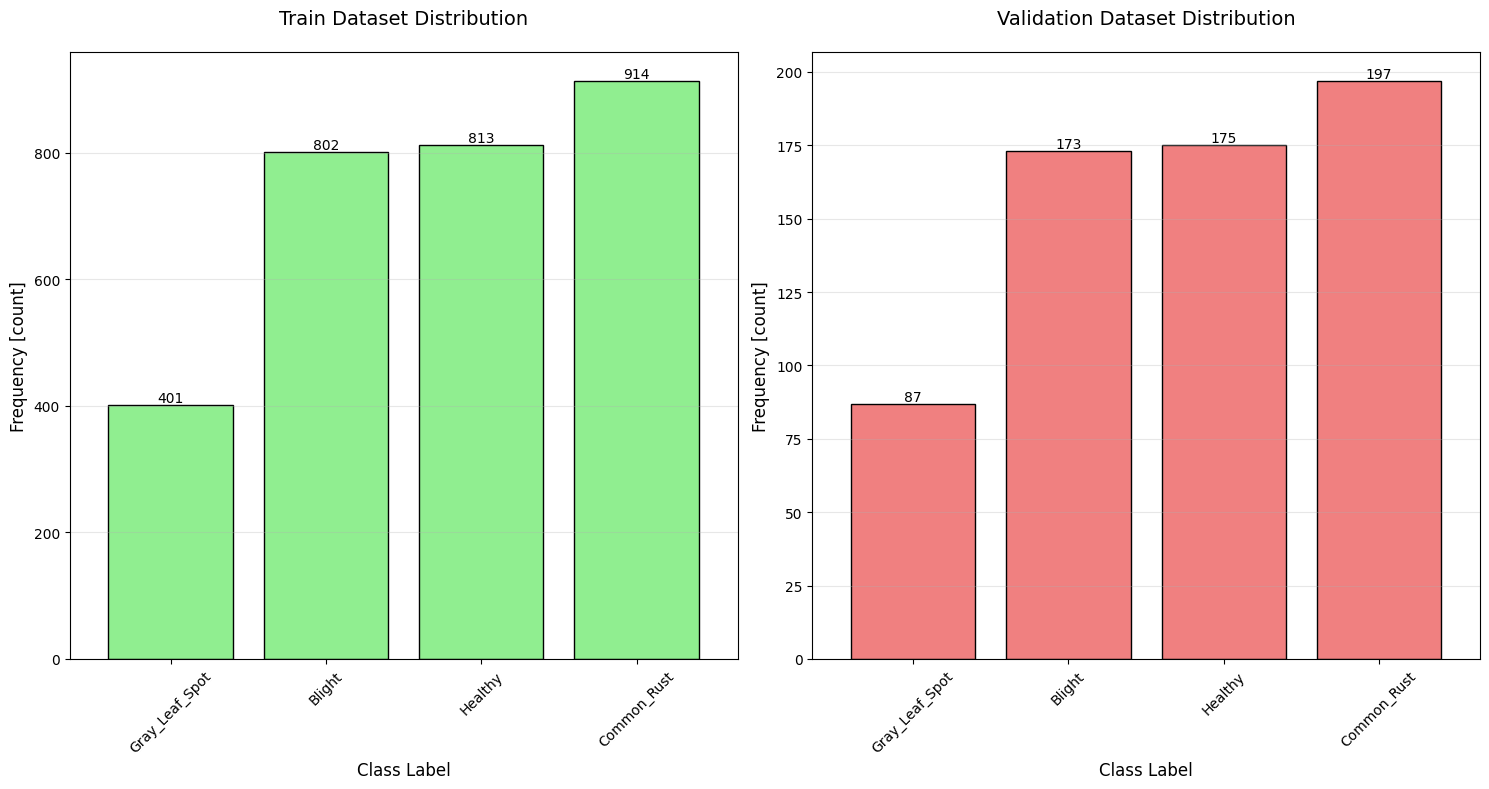


Class Imbalance Analysis (Threshold: 0.5):
  Imbalanced: Yes
  Imbalance ratio (Min/Max): 0.439
  Majority class: Common_Rust (914 samples)
  Minority class: Gray_Leaf_Spot (401 samples)
  Recommendation: Consider data augmentation or resampling strategies.
Train DataLoader created with 92 batches.
Val DataLoader created with 20 batches.
Test_submission DataLoader created with 20 batches.

Inspecting a batch from Training Data...
Batch size: 32
Image tensor shape: torch.Size([32, 3, 224, 224])


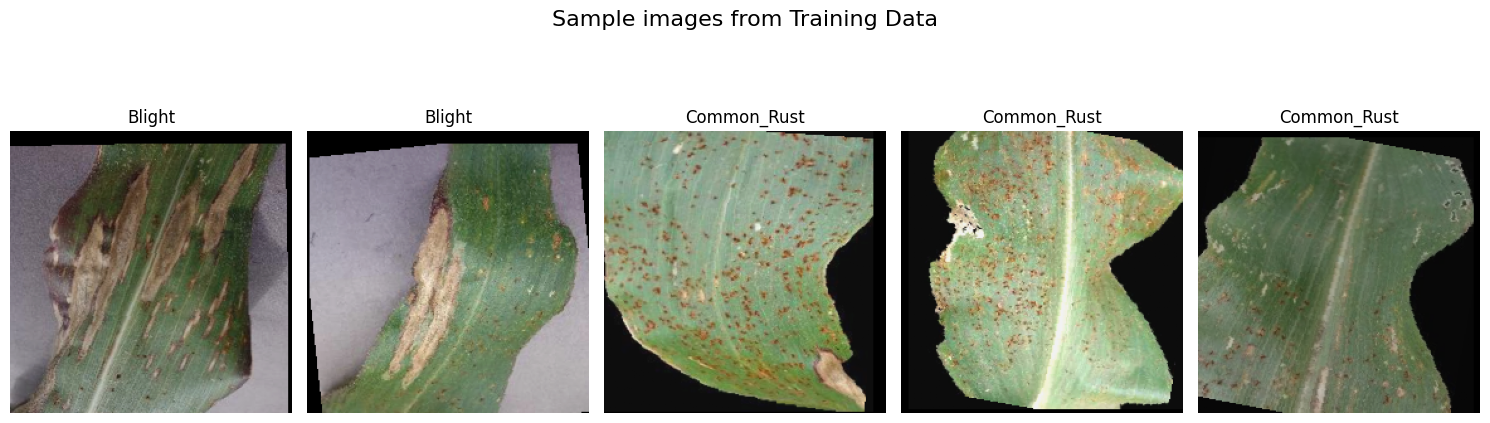


Inspecting a batch from Test Submission Data...
Batch size: 32
Image tensor shape: torch.Size([32, 3, 224, 224])


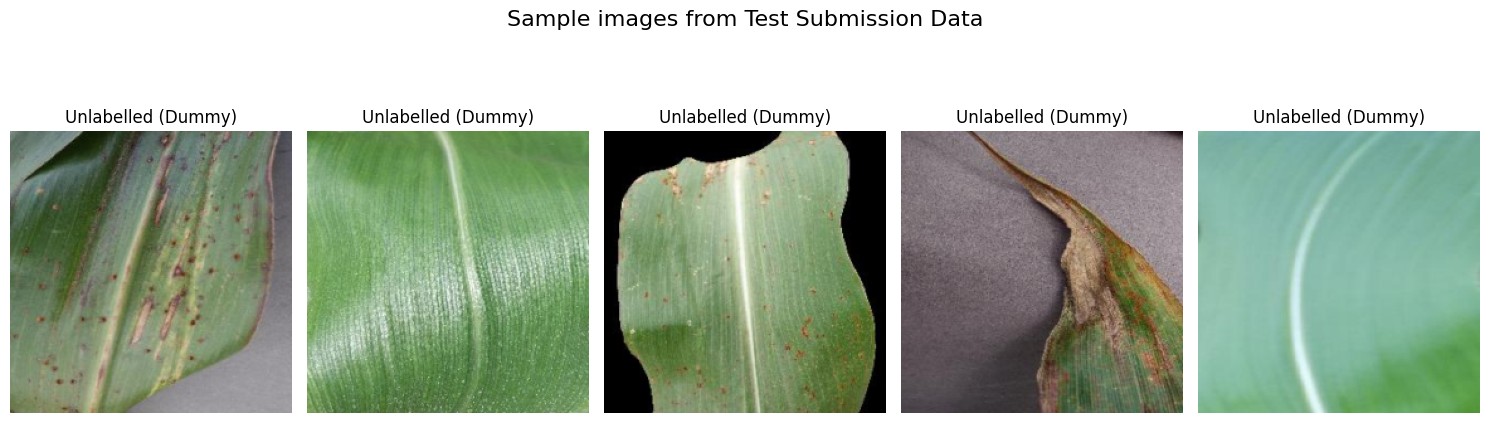

Model architecture:

Training Configuration:
Loss Function: CrossEntropyLoss
Optimizer: Adam (Learning Rate: 0.001)

--- Starting Model Training ---


Epoch 1/10 Validation: 100%|██████████| 20/20 [00:04<00:00,  4.64it/s]


Epoch 1/10 | Train Loss: 0.7957 - Train Acc: 69.62% | Val Loss: 0.7961 - Val Acc: 67.09%


Epoch 2/10 Validation: 100%|██████████| 20/20 [00:04<00:00,  4.82it/s]


Epoch 2/10 | Train Loss: 0.5498 - Train Acc: 78.16% | Val Loss: 0.4931 - Val Acc: 78.64%


...

Epoch 8/10 | Train Loss: 0.3866 - Train Acc: 83.82% | Val Loss: 0.3360 - Val Acc: 84.18%


Epoch 9/10 Validation: 100%|██████████| 20/20 [00:05<00:00,  3.94it/s]


Epoch 9/10 | Train Loss: 0.3605 - Train Acc: 85.19% | Val Loss: 0.3459 - Val Acc: 83.54%


Epoch 10/10 Validation: 100%|██████████| 20/20 [00:05<00:00,  3.35it/s]


Epoch 10/10 | Train Loss: 0.3542 - Train Acc: 85.22% | Val Loss: 0.3519 - Val Acc: 84.65%


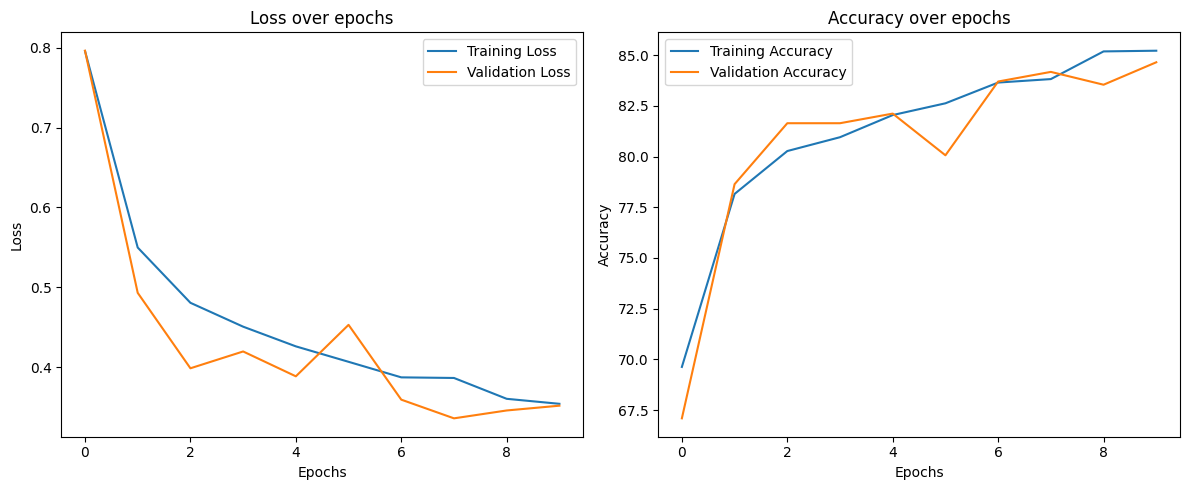


--- Evaluating Model on Validation Set ---


Evaluating Validation: 100%|██████████| 20/20 [00:05<00:00,  3.44it/s]



--- Classification Report for Validation Set ---
                precision    recall  f1-score   support

        Blight       0.70      0.83      0.76       173
   Common_Rust       0.97      0.93      0.95       197
Gray_Leaf_Spot       0.59      0.38      0.46        87
       Healthy       0.96      1.00      0.98       175

      accuracy                           0.85       632
     macro avg       0.81      0.78      0.79       632
  weighted avg       0.84      0.85      0.84       632



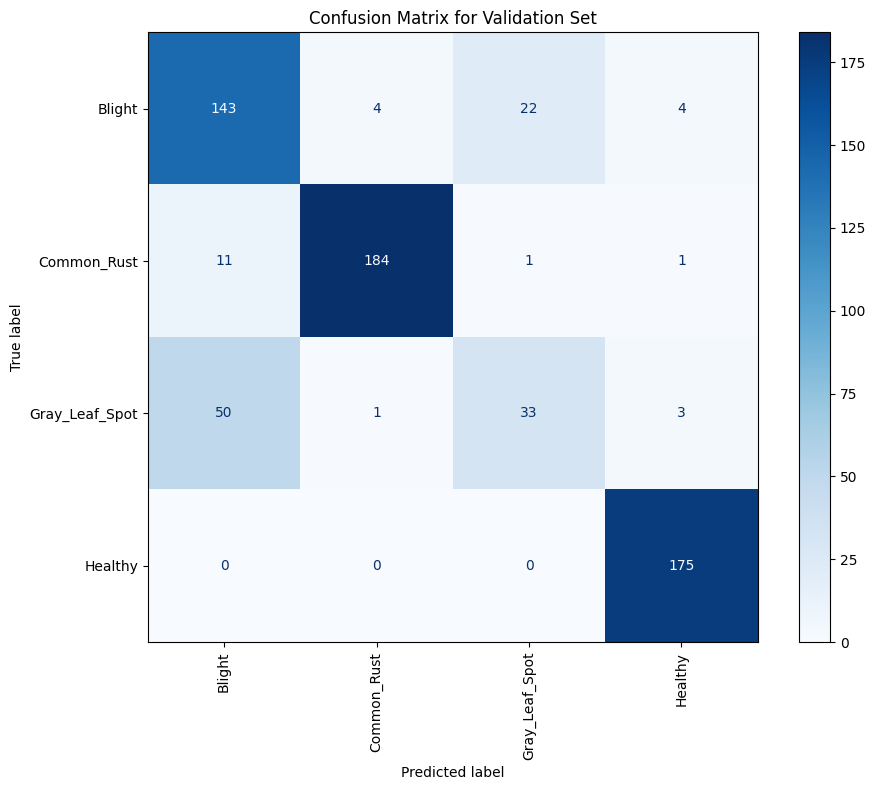


--- Generating Submission File: submission_2.csv ---


Generating Predictions: 100%|██████████| 20/20 [00:05<00:00,  3.43it/s]



Submission DataFrame Head:
             ID  Blight  Common_Rust  Gray_Leaf_Spot  Healthy
0  image_000001 0.42579      0.00727         0.56676  0.00018
1  image_000002 0.00054      0.00022         0.00004  0.99920
2  image_000003 0.00215      0.99645         0.00089  0.00051
3  image_000004 0.79895      0.00081         0.20024  0.00000
4  image_000005 0.00043      0.00029         0.00005  0.99923

Submission file 'submission_2.csv' created successfully!
Model saved successfully to trained_crop_disease_model.pth

--- Pipeline Finished ---


In [22]:
if __name__ == "__main__":
    print("--- Starting Crop Disease Classification Pipeline ---")

    # --- 1. Setup Device ---
    device = setup_device()

    # --- 2. Setup Data Directories ---
    base_data_path = "crop pictures" # IMPORTANT: Ensure this directory exists relative to your script
                                     # and contains 'train', 'val', and 'test' subfolders.
    data_dirs = setup_data_directories(base_data_path)

    # --- 3. Get Class Information ---
    # Classes are derived from the training data, as test data is unlabelled.
    if 'train' in data_dirs and os.path.exists(data_dirs['train']):
        classes, num_classes = get_class_information(data_dirs['train'])
    else:
        print("Error: Training directory not found. Cannot determine classes. Exiting.")
        exit() # Cannot proceed without knowing the classes

    # --- 4. Create Transforms (with optional enhancements) ---
    image_size = (224, 224)

    # Example: Apply Wiener deblurring, Gaussian noise reduction, and some sharpening/contrast
    # Adjust parameters based on your data analysis!
    # For training, you can randomly apply these as augmentation.
    # For validation/test, you would apply deterministic enhancements if the data is inherently blurry/noisy.
    
    # Example for base transform (applied to val/test, or if all data is inherently bad)
    val_test_transform = create_base_transforms(
        image_size=image_size,
        deblur_method="none", #"wiener" or "lucy_richardson"
        psf_size=5,
        noise_reduct_method="none", #"gaussian", "median", "bilateral"
        nr_kernel_size=5,
        sharpen_factor=1.0, # e.g., 1.2 to slightly sharpen all val/test images
        contrast_enhance_method="none", # e.g., "equalize" or "adapt_equalize"
        ce_factor=1.0,
        color_correct_method="none",
        cc_factor=1.0
    )

    # Example for training transform (includes augmentation and can include enhancement)
    # You might want to apply some of these enhancements randomly as part of augmentation.
    train_transform = create_augmented_transforms(
        image_size=image_size,
        augmentation_strength="medium",
        deblur_method="none", # You could apply a *simulated* blur as augmentation, then deblur.
        psf_size=5,
        noise_reduct_method="none",
        nr_kernel_size=5,
        sharpen_factor_range=(1.0, 1.3), # Apply random sharpening
        contrast_enhance_method="contrast", # Random contrast adjustment
        ce_factor_range=(0.8, 1.2),
        color_correct_method="saturation", # Random saturation adjustment
        cc_factor_range=(0.8, 1.2)
    )

    # --- 5. Create Datasets ---
    datasets_dict = create_datasets(data_dirs, train_transform, val_test_transform, val_test_transform)
    train_dataset = datasets_dict.get('train')
    val_dataset = datasets_dict.get('val')
    test_submission_dataset = datasets_dict.get('test_submission')

    if not train_dataset or not val_dataset:
        print("Error: Training or Validation dataset not found. Cannot proceed with training. Exiting.")
        exit()

    # --- 6. Data Analysis and Visualization ---
    print("\n--- Initial Data Distribution Analysis ---")
    distributions = {
        "train": analyze_class_distribution(train_dataset, "Training Dataset"),
        "validation": analyze_class_distribution(val_dataset, "Validation Dataset"),
    }
    if test_submission_dataset:
        distributions["test_submission"] = analyze_class_distribution(test_submission_dataset, "Test Submission Dataset")

    visualize_class_distributions(distributions) # Visualizes only labelled datasets

    # Detect imbalance in training data
    imbalance_results = detect_class_imbalance(distributions['train'])

    # --- 7. Create DataLoaders ---
    batch_size = 32
    num_workers = 4 if torch.cuda.is_available() else 0 # Use more workers on GPU
    dataloaders = create_dataloaders(datasets_dict, batch_size, num_workers)

    train_loader = dataloaders.get('train')
    val_loader = dataloaders.get('val')
    test_submission_loader = dataloaders.get('test_submission')

    # Inspect a batch from each DataLoader
    inspect_batch(train_loader, "Training Data", num_images=5)
    if test_submission_loader:
        inspect_batch(test_submission_loader, "Test Submission Data", num_images=5)

    # --- 8. Model Setup ---
    model, optimizer, loss_fn = setup_training_components(num_classes, learning_rate=0.001, image_size=image_size)
    model.to(device) # Ensure model is on the correct device after creation

    # --- 9. Train Model ---
    epochs = 10 # You can adjust the number of epochs here
    train_losses, val_losses, train_accuracies, val_accuracies = \
        train_model(model, optimizer, loss_fn, train_loader, val_loader, epochs=epochs, device=device)

    plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

    # --- 10. Evaluate Model on Validation Set ---
    evaluate_model(model, val_loader, device, classes, split_name="Validation")

    # --- 11. Generate Submission File ---
    if test_submission_loader:
        generate_submission_file(model, test_submission_loader, classes, device, output_filename="submission_2.csv")
    else:
        print("Warning: Test submission DataLoader not available. Skipping submission file generation.")

    # --- 12. Save Trained Model ---
    save_model(model, path="trained_crop_disease_model.pth")

    print("\n--- Pipeline Finished ---")